In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Sistema de etiquetas estilo SPSS
def set_labels(df, label_dict):
    """Asigna etiquetas (variable labels) a las columnas del DataFrame"""
    df.attrs['variable_labels'] = label_dict
    return df

def get_label(df, col_name):
    """Obtiene la etiqueta de una columna"""
    labels = df.attrs.get('variable_labels', {})
    return labels.get(col_name, col_name)

def display_labeled(df, show_labels=True):
    """Muestra un DataFrame con etiquetas en los encabezados"""
    if not show_labels or 'variable_labels' not in df.attrs:
        return df
    
    labels = df.attrs['variable_labels']
    df_display = df.copy()
    df_display.columns = [labels.get(col, col) for col in df_display.columns]
    return df_display

def labeled_head(df, n=5, show_labels=True):
    """Muestra las primeras n filas con etiquetas"""
    return display_labeled(df.head(n), show_labels)

def labeled_info(df, show_labels=True):
    """Muestra info del DataFrame con etiquetas"""
    labels = df.attrs.get('variable_labels', {})
    print("\n" + "="*80)
    print("INFORMACIÓN DEL DATASET CON ETIQUETAS")
    print("="*80)
    for col in df.columns:
        label = labels.get(col, col)
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        null_pct = (null_count / len(df)) * 100
        print(f"{col:15} | {label:70} | {str(dtype):10} | {null_count:4} ({null_pct:5.1f}%)")
    print("="*80 + "\n")

def labeled_describe(df, show_labels=True, **kwargs):
    """Muestra describe con etiquetas"""
    desc = df.describe(**kwargs)
    if show_labels and 'variable_labels' in df.attrs:
        labels = df.attrs['variable_labels']
        desc.columns = [labels.get(col, col) for col in desc.columns]
    return desc

In [6]:
dfpymes = pd.read_excel('data/ia_pymes.xlsx')

# Diccionarios de mapeo: nombre_corto -> nombre_original (etiqueta)
labels = {
    'id': 'ID',
    'sexo': 'SEXO',
    'edad': 'RANGO ETARIO',
    'niveduc': '¿NIVEL EDUCACIONAL?',
    'ocupacion': '¿TIPO DE TRABAJO?',
    'nse': 'GRUPO NSE',
    'p01': 'De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)',
    'p01_otro': 'De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))',
    'p02': 'Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)',
    'p02_otro': 'Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))',
    'p03': '¿Qué te frena hoy para hacer crecer tu negocio? (Total)',
    'p03_otro': '¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique))',
    'p04': 'Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?'
}

# Renombrar columnas
dfpymes = dfpymes.rename(columns={v: k for k, v in labels.items()})

# Asignar etiquetas
dfpymes = set_labels(dfpymes, labels)

print("✓ Datos cargados y etiquetado. Usa labeled_head(), labeled_info() para ver con etiquetas.")
labeled_head(dfpymes)

✓ Datos cargados y etiquetado. Usa labeled_head(), labeled_info() para ver con etiquetas.


,ID,SEXO,RANGO ETARIO,¿NIVEL EDUCACIONAL?,¿TIPO DE TRABAJO?,GRUPO NSE,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)","De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))","Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)","Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))",¿Qué te frena hoy para hacer crecer tu negocio? (Total),¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique)),"Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?"
0,1,MASCULINO,[51 - 60],MEDIA COMPLETA,JUBILADO(A),D+E,Llevar contabilidad,NaN,Familia o amigos,NaN,Falta de capital,NaN,1 a 2 horas
1,2,FEMENINO,[51 - 60],TÉCNICA SUPERIOR COMPLETA,ESTUDIANTE,C3,Atender clientes,NaN,Redes sociales / internet,NaN,Falta de capital,NaN,1 a 2 horas
2,3,MASCULINO,[41 - 50],UNIVERSITARIA COMPLETA,EJECUTIVO(A) MEDIO(A) / PROFESIONAL INDEPENDIENTE,ABC1,Hacer publicidad,NaN,Familia o amigos,NaN,Falta de capital,NaN,Más de 4 horas
3,4,FEMENINO,[31 - 40],TÉCNICA SUPERIOR INCOMPLETA,DUEÑO(A) DE CASA,C3,Llevar contabilidad,NaN,Familia o amigos,NaN,Falta de capital,NaN,1 hora o menos
4,5,MASCULINO,[18 - 30],UNIVERSITARIA COMPLETA,EMPLEADO(A) ADMINISTRATIVO(A) / TÉCNICO,ABC1,Atender clientes,NaN,Nadie / lo resuelvo solo,NaN,Falta de capital,NaN,Más de 4 horas


In [7]:
# Convertir todos los valores a minúsculas
def lowercase_df(df):
    """
    Convierte todos los valores de string en el DataFrame a minúsculas.
    Preserva etiquetas, tipos de datos y valores no-string (NaN, números, etc).
    """
    df_lower = df.copy()
    labels = df.attrs.get('variable_labels', {})
    
    for col in df_lower.columns:
        # Aplicar lower() solo a valores string
        df_lower[col] = df_lower[col].apply(
            lambda x: x.lower() if isinstance(x, str) else x
        )
    
    # Restaurar etiquetas
    if labels:
        df_lower = set_labels(df_lower, labels)
    
    return df_lower

# Aplicar conversión a minúsculas
dfpymes = lowercase_df(dfpymes)

print("✓ Todos los valores convertidos a minúsculas")
print("\nEjemplo - Primeras filas de dfpymes:")
labeled_head(dfpymes, n=3)

✓ Todos los valores convertidos a minúsculas

Ejemplo - Primeras filas de dfpymes:


,ID,SEXO,RANGO ETARIO,¿NIVEL EDUCACIONAL?,¿TIPO DE TRABAJO?,GRUPO NSE,"De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Total)","De las tareas de tu negocio (atender clientes, hacer publicidad, llevar cuentas, controlar inventario), ¿cuál te quita más tiempo hoy? (Otro (especifique))","Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Total)","Cuando necesitas ayuda para tu negocio, ¿a quién recurres primero (familia, redes sociales, un curso, SERCOTEC u otra institución)? (Otro (especifique))",¿Qué te frena hoy para hacer crecer tu negocio? (Total),¿Qué te frena hoy para hacer crecer tu negocio? (Otro (especifique)),"Si una herramienta digital te ayudara a vender más o ahorrar tiempo, ¿cuánto tiempo semanal estarías dispuesto a dedicar para aprender a usarla?"
0,1,masculino,[51 - 60],media completa,jubilado(a),d+e,llevar contabilidad,NaN,familia o amigos,NaN,falta de capital,NaN,1 a 2 horas
1,2,femenino,[51 - 60],técnica superior completa,estudiante,c3,atender clientes,NaN,redes sociales / internet,NaN,falta de capital,NaN,1 a 2 horas
2,3,masculino,[41 - 50],universitaria completa,ejecutivo(a) medio(a) / profesional independiente,abc1,hacer publicidad,NaN,familia o amigos,NaN,falta de capital,NaN,más de 4 horas


In [8]:
# Análisis de valores únicos para categorizacion
print("="*80)
print("ANÁLISIS DE VALORES ÚNICOS")
print("="*80)

cols_to_analyze = ['sexo', 'edad', 'niveduc', 'ocupacion']

# for col in cols_to_analyze:
#     print(f"\n{col.upper()}:")
#     print(f"Valores únicos ({dfcomp[col].nunique()}):")
#     for val in sorted(dfcomp[col].dropna().unique()):
#         count = (dfcomp[col] == val).sum()
#         pct = (count / len(dfcomp)) * 100
#         print(f"  • {val:40} ({count:3} | {pct:5.1f}%)")

for col in cols_to_analyze:
    print(f"\n{col.upper()}:")
    #print(f"Valores únicos ({dfcomp[col].nunique()}):")

    for val in sorted(dfpymes[col].dropna().unique()):
        count = (dfpymes[col] == val).sum()
        pct = (count / len(dfpymes)) * 100

        print(f"{str(val):40} ({count:3} | {pct:5.1f}%)")

    print(f"{'-' * 60}")
    print(f"{'Total':40} ({len(dfpymes):3} | {100:5.1f}%)")

ANÁLISIS DE VALORES ÚNICOS

SEXO:
femenino                                 (192 |  52.2%)
masculino                                (176 |  47.8%)
------------------------------------------------------------
Total                                    (368 | 100.0%)

EDAD:
[18 - 30]                                ( 55 |  14.9%)
[31 - 40]                                ( 75 |  20.4%)
[41 - 50]                                ( 86 |  23.4%)
[51 - 60]                                ( 79 |  21.5%)
[61+]                                    ( 73 |  19.8%)
------------------------------------------------------------
Total                                    (368 | 100.0%)

NIVEDUC:
básica completa                          (  4 |   1.1%)
básica incompleta                        (  1 |   0.3%)
media completa                           ( 97 |  26.4%)
media incompleta                         (  6 |   1.6%)
postgrado                                ( 10 |   2.7%)
técnica superior completa                ( 

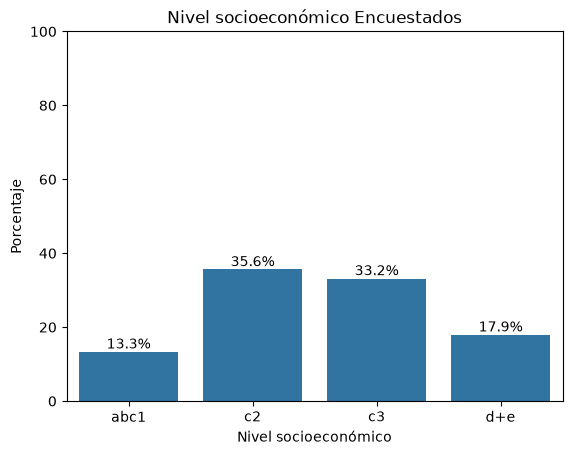

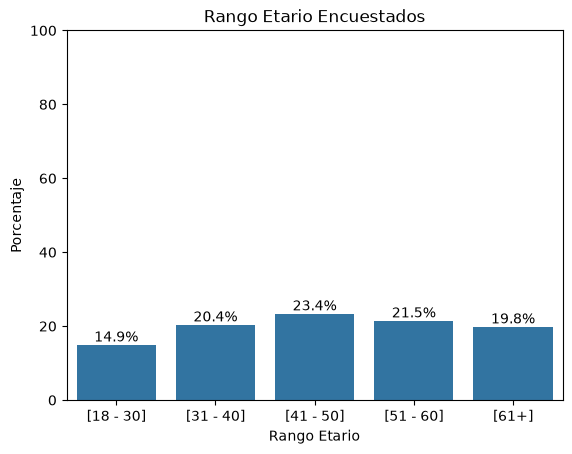

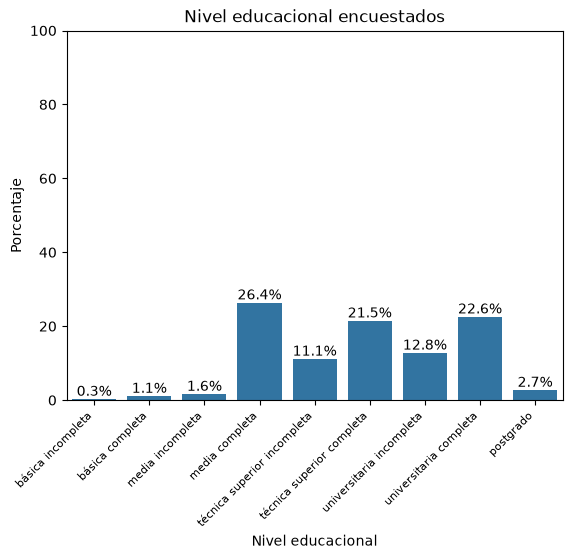

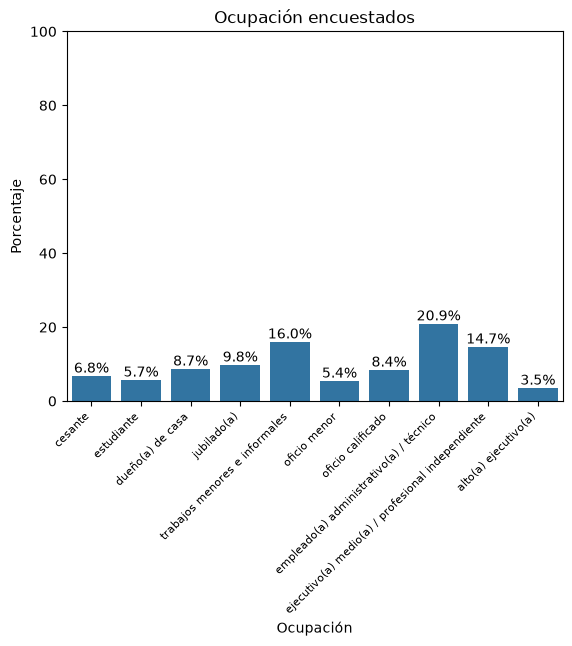

In [9]:
order_nse = ['abc1',
			 'c2',
			 'c3',
			 'd+e']

order_edad = ['[18 - 30]',
			'[31 - 40]',
			'[41 - 50]',
			'[51 - 60]',
			'[61+]'
			]

order_niveduc =['básica incompleta',
				'básica completa',
				'media incompleta',
				'media completa',
				'técnica superior incompleta',
				'técnica superior completa',
				'universitaria incompleta',
				'universitaria completa',
				'postgrado'
]

order_ocupacion= ['cesante',
				  'estudiante',
				  'dueño(a) de casa',
				  'jubilado(a)',
				  'trabajos menores e informales',
				  'oficio menor',
				  'oficio calificado',
				  'empleado(a) administrativo(a) / técnico',
				  'ejecutivo(a) medio(a) / profesional independiente',
				  'alto(a) ejecutivo(a)'
				  ]

# GRAFICO NSE
ax = sns.countplot(
	data=dfpymes,
	x='nse',
	stat='percent',
	order=order_nse
)

# ax.containers[0] contiene el grupo de barras dibujadas
# bar_label agrega el valor de cada barra encima de ella
# fmt='%.1f%%' da formato con 1 decimal y el símbolo de porcentaje (ej: 23.4%)
ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Nivel socioeconómico')
plt.ylim(0,100)
plt.title("Nivel socioeconómico Encuestados")
plt.show()

# GRAFICO EDAD
ax = sns.countplot(
	data=dfpymes,
	x='edad',
	stat='percent',
	order=order_edad
)

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Rango Etario')
plt.ylim(0,100)
plt.title("Rango Etario Encuestados")
plt.show()

# GRAFICO NIVEDUC
ax = sns.countplot(
	data=dfpymes,
	x='niveduc',
	stat='percent',
	order=order_niveduc
)

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Nivel educacional')
plt.ylim(0,100)
plt.title("Nivel educacional encuestados")
plt.xticks(rotation=45, ha='right', fontsize='8')
plt.show()

# GRAFICO OCUPACION
ax = sns.countplot(
	data=dfpymes,
	x='ocupacion',
	stat='percent',
	order=order_ocupacion
)

ax.bar_label(ax.containers[0], fmt='%.1f%%')

plt.ylabel('Porcentaje')
plt.xlabel('Ocupación')
plt.ylim(0,100)
plt.title("Ocupación encuestados")
plt.xticks(rotation=45, ha='right', fontsize='8' )
plt.show()
